# Survival Analysis

## 1. Notebook Styling and Library Installation

In [1]:
!conda install -c sebp scikit-survival --yes 
# !pip install lifelines
!pip install xgbse

Channels:
 - sebp
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.1.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [2]:
import numpy as np # Library for math operations
import pandas as pd # Library for data handling
from sksurv.nonparametric import kaplan_meier_estimator # Library for survival analysis
import matplotlib.pyplot as plt # Library for plotting
import seaborn as sns # Another library for plotting
plt.style.use('fivethirtyeight') # Set the styling to FiveThirtyEight setting.
from datetime import date

## 2. Read & Process the Data

In [3]:
trainInput = pd.read_csv('trainInput.csv')
testInput = pd.read_csv('testInput.csv')

In [4]:
trainData = trainInput.drop(columns = ['id','purchased', 'days_on_market'])
trainLabels = trainInput['purchased']
testData = testInput.drop(columns = ['id','purchased', 'days_on_market'])
testLabels = testInput['purchased']

In [5]:
trainInput.purchased.value_counts()

purchased
1    8458
0    7404
Name: count, dtype: int64

## 3. Data Augmentation:

In [6]:
trainData[['product_id']] = trainData[['product_id']].astype(str)

testData[['product_id']] = testData[['product_id']].astype(str)

In [7]:
!pip install feature-engine

### 3.1. Treat Categorical Variables:

In [8]:
trainData.head(10)

,product_id,brand,price,color
0,459,samsung,240.53,silver
1,483,samsung,280.91,silver
2,260,apple,746.09,black
3,626,apple,1003.85,gold
4,420,samsung,250.97,silver
5,372,samsung,727.69,silver
6,420,samsung,250.69,black
7,528,xiaomi,347.21,white
8,26,apple,360.34,gold
9,252,apple,1174.09,black


In [9]:
from feature_engine.encoding import RareLabelEncoder

enc = RareLabelEncoder(tol=0.001, n_categories = 2)

trainData, testData = enc.fit_transform(trainData), enc.transform(testData)

### 3.2. Drop Psudo-Constant Features (Small Variation)

In [10]:
from feature_engine.selection import DropConstantFeatures

con = DropConstantFeatures(tol=.99)

trainData, testData = con.fit_transform(trainData), con.transform(testData)

### 3.3. Encode the Categorical Features

In [11]:
from feature_engine.encoding import WoEEncoder

enc2 = WoEEncoder()

trainData, testData = enc2.fit_transform(trainData,trainLabels), enc2.transform(testData)

## 4. Kaplan-Meier (for data exploration)

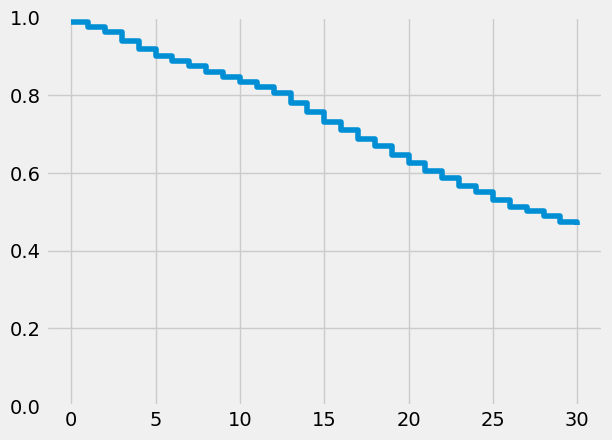

In [12]:
from sksurv.nonparametric import kaplan_meier_estimator 

time, survival_prob = \
    kaplan_meier_estimator(
    trainInput.purchased.astype(bool), 
    trainInput["days_on_market"]) 

fig, ax = plt.subplots()
sns.lineplot(y = survival_prob, x=time, drawstyle='steps-post')
ax.set_ylim(0,1)
plt.show()

## 5. XGBoost Survival Model

In [13]:
from sklearn.preprocessing import MinMaxScaler

# importing model and utils from xgbse
from xgbse import (XGBSEKaplanNeighbors, 
                   XGBSEDebiasedBCE,
                   XGBSEKaplanTree,
                   XGBSEStackedWeibull,
                   XGBSEBootstrapEstimator)

from xgbse.converters import convert_to_structured

# importing metrics
from xgbse.metrics import (
    concordance_index,
    approx_brier_score,
    dist_calibration_score
)

scaler = MinMaxScaler()

trainData = pd.DataFrame(scaler.fit_transform(trainData), 
                         columns=trainData.columns)

testData = pd.DataFrame(scaler.fit_transform(testData), 
                         columns=testData.columns)

X = trainData
y = convert_to_structured(trainInput['days_on_market'], trainLabels)

X_val = testData
y_val = convert_to_structured(testInput['days_on_market'], testLabels)

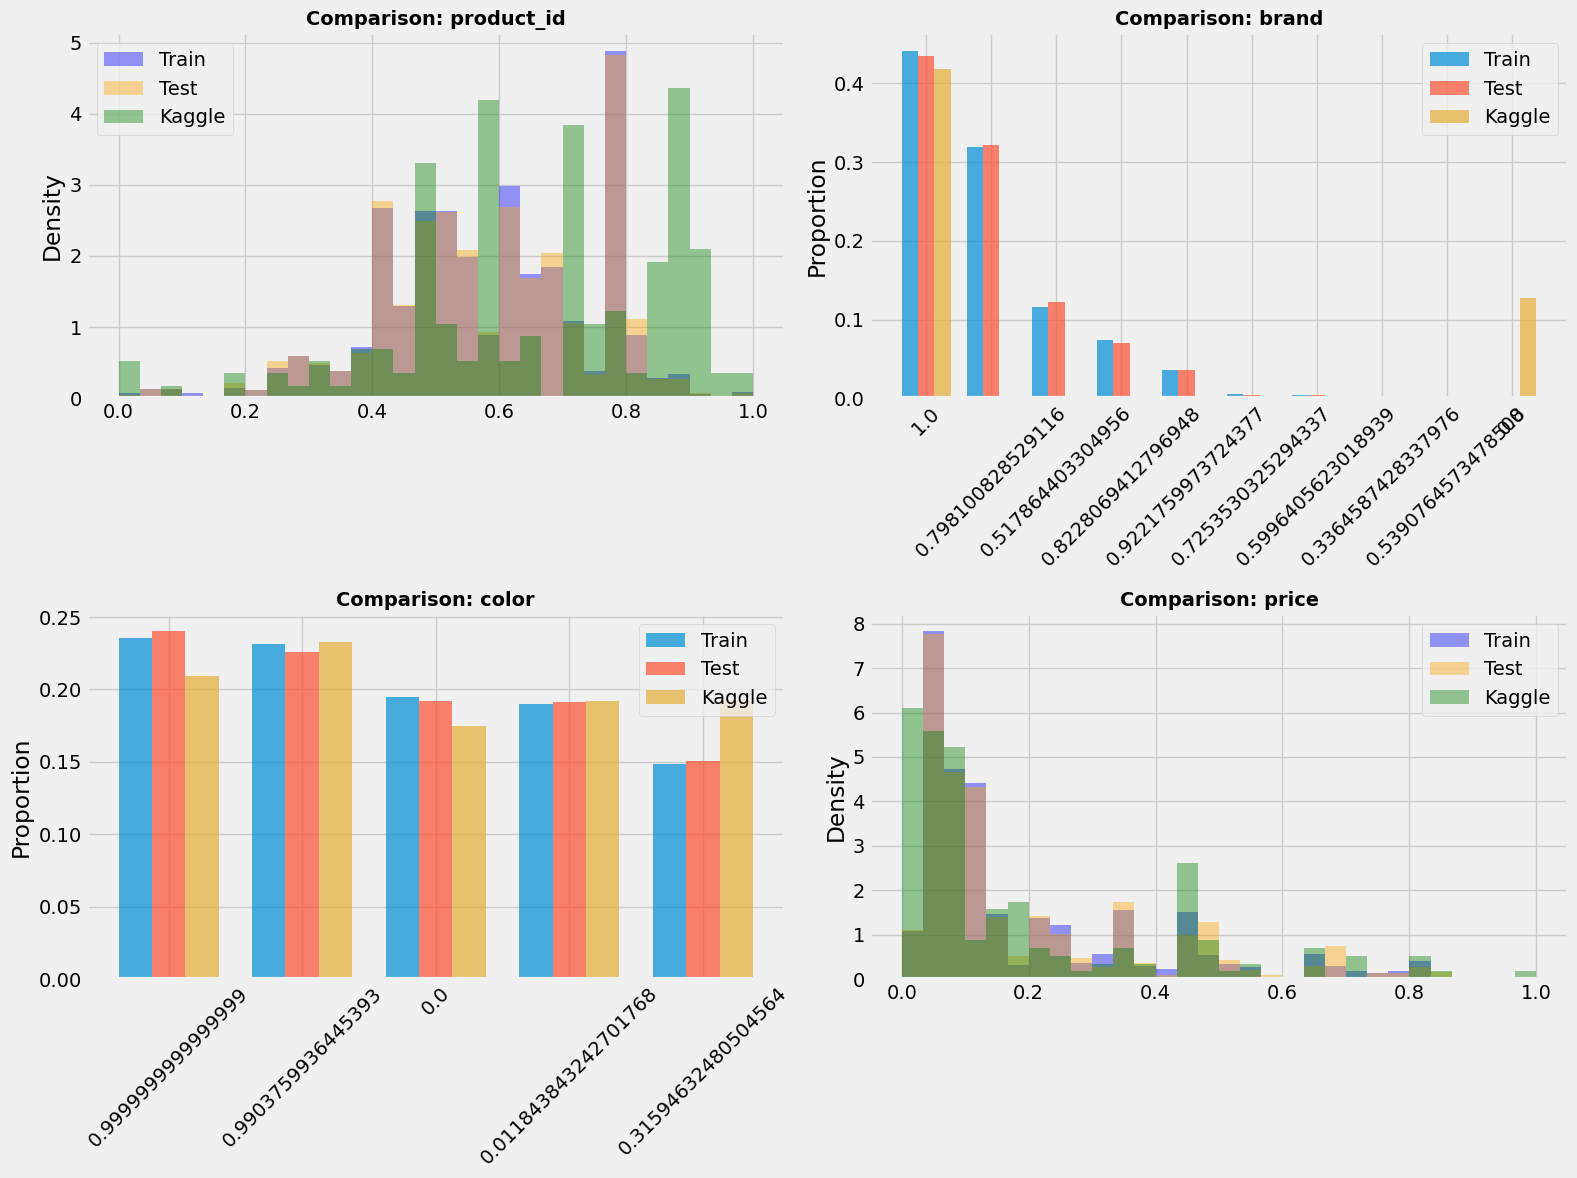

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

#columns that are shared between all datasets
cols_to_plot = ["product_id", "brand", "color", "price"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    if trainData[col].dtype == 'object' or col in ["brand", "color"]:
        #bins
        top_cats = trainData[col].value_counts().nlargest(10).index
        
        #normalize by calculating percentages because datasets are different sizes
        train_counts = trainData[col].value_counts(normalize=True).loc[top_cats]
        test_counts = testData[col].value_counts(normalize=True).reindex(top_cats)
        kaggle_counts = kaggle[col].value_counts(normalize=True).reindex(top_cats)

        width = 0.25
        x_vals = range(len(top_cats))
        
        axes[i].bar([x - width for x in x_vals], train_counts, width, label='Train', alpha=0.7)
        axes[i].bar(x_vals, test_counts, width, label='Test', alpha=0.7)
        axes[i].bar([x + width for x in x_vals], kaggle_counts, width, label='Kaggle', alpha=0.7)
        
        axes[i].set_xticks(x_vals)
        axes[i].set_xticklabels(top_cats, rotation=45)
        axes[i].set_ylabel('Proportion')
    else:
        axes[i].hist(trainData[col].dropna(), bins=30, alpha=0.4, label='Train', density=True, color='blue')
        axes[i].hist(testData[col].dropna(), bins=30, alpha=0.4, label='Test', density=True, color='orange')
        axes[i].hist(kaggle[col].dropna(), bins=30, alpha=0.4, label='Kaggle', density=True, color='green')
        axes[i].set_ylabel('Density')

    axes[i].set_title(f'Comparison: {col}', fontsize=14, fontweight='bold')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [ ]:
# # fitting xgbse model
# xgbse_model = XGBSEKaplanNeighbors(n_neighbors=5)
# xgbse_model.fit(
#     X, y,
#     validation_data=(X_val, y_val),
#     early_stopping_rounds=20,  # Stops training if validation metric doesn't improve for 20 rounds
#     verbose_eval=False  # Prints the evaluation metric on the validation set
# )

# # predicting
# preds = xgbse_model.predict(X_val)

# # # running metrics
# print(f'C-index: {concordance_index(y_val, preds)}')
# #print(f'Avg. Brier Score: {approx_brier_score(y_val, preds)}')

In [ ]:
# # fitting xgbse model
# xgbse_model = XGBSEDebiasedBCE()
# xgbse_model.fit(
#     X, y,
#     validation_data=(X_val, y_val),
#     early_stopping_rounds=20,  # Stops training if validation metric doesn't improve for 20 rounds
#     verbose_eval=False  # Prints the evaluation metric on the validation set
# )

# # predicting
# preds = xgbse_model.predict(X_val)

# # # running metrics
# print(f'C-index: {concordance_index(y_val, preds)}')
# #print(f'Avg. Brier Score: {approx_brier_score(y_val, preds)}')

In [ ]:
# # fitting xgbse model
# xgbse_model = XGBSEStackedWeibull()
# xgbse_model.fit(
#     X_val_enhanced, y,
#     validation_data=(X_val_enhanced, y_val),
#     early_stopping_rounds=20,  # Stops training if validation metric doesn't improve for 20 rounds
#     verbose_eval=False  # Prints the evaluation metric on the validation set
# )

# # predicting
# preds = xgbse_model.predict(X_val_enhanced)

# # # running metrics
# print(f'C-index: {concordance_index(y_val, preds)}')

In [ ]:
# def create_features(df):
#     original_rows = len(df)
#     df['log_price'] = np.log1p(df['price'])
#     df['price_squared'] = df['price'] ** 2
#     df['price_percentile'] = df['price'].rank(pct=True)
#     return df

# X_enhanced = create_features(X.copy())
# X_val_enhanced = create_features(X_val.copy())
# kaggle_enhanced = create_features(kaggle.copy())

In [19]:
# fitting xgbse model

xgb_params={
        'max_depth': 12,
        'learning_rate': 0.01,
        'min_child_weight': 3,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'gamma': 0.1,
        'reg_alpha': 0.1,
        'reg_lambda': 1.5,
        'n_estimators': 100
    }

base = XGBSEStackedWeibull(xgb_params=xgb_params)
xgbse_model = XGBSEBootstrapEstimator(base_estimator = base,
                                      n_estimators = 30,
                                      random_state = 1)
xgbse_model.fit(
    X, y,
    validation_data=(X_val, y_val),
    early_stopping_rounds=20,  # Stops training if validation metric doesn't improve for 20 rounds
    verbose_eval=False  # Prints the evaluation metric on the validation set
)

# predicting
preds = xgbse_model.predict(X_val)

# # running metrics
print(f'C-index: {concordance_index(y_val, preds)}')

/opt/conda/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [17:58:37] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1744329020674/work/src/learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [17:58:37] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1744329020674/work/src/learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [17:58:37] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1744329020674/work/src/learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [17:58:38] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1744329020674/work/src/learner.cc

C-index: 0.7584932155759098


In [ ]:
import optuna

def objective(trial):
    xgb_params = {
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'gamma': trial.suggest_float('gamma', 0.1, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 5),
        'n_estimators': trial.suggest_int('n_estimators', 200, 800)
    }
    
    n_bootstrap = trial.suggest_int('n_bootstrap', 40, 100)
    
    base = XGBSEStackedWeibull(xgb_params=xgb_params)
    model = XGBSEBootstrapEstimator(
        base_estimator=base,
        n_estimators=30,
        random_state=1
    )
    
    model.fit(X, y, validation_data=(X_val, y_val), 
              early_stopping_rounds=20, verbose_eval=False)
    preds = model.predict(X_val)
    
    return concordance_index(y_val, preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5) #used 100 for top score

print(f"\nBest C-index: {study.best_value}")
print(f"Best params: {study.best_params}")

In [ ]:
best_params = {'max_depth': 10, 
               'learning_rate': 0.08666953645488727, 
               'min_child_weight': 1, 
               'subsample': 0.7368453926820681, 
               'colsample_bytree': 0.8919393373071122, 
               'gamma': 4.856211253035163, 
               'reg_alpha': 2.727110378232862, 
               'reg_lambda': 2.500738513047743, 
               'n_estimators': 260, 
               'n_bootstrap': 51}

base = XGBSEStackedWeibull(xgb_params=best_params)
xgbse_bootstrapping = XGBSEBootstrapEstimator(base_estimator = base,
                                      n_estimators = 30,
                                      random_state = 1)
xgbse_bootstrapping.fit(
    X, y,
    validation_data=(X_val, y_val),
    early_stopping_rounds=20,
    verbose_eval=False
)

# predicting
preds = xgbse_bootstrapping.predict(X_val)

# # running metrics
print(f'C-index: {concordance_index(y_val, preds)}')

In [ ]:
xgbse_model.feature_importances_

## 6. Apply to Kaggle Data

In [15]:
kaggle = pd.read_csv('kaggle.csv')
submission = kaggle.copy()
kaggle[['product_id']] = kaggle[['product_id']].astype(str)

In [16]:
kaggle.head()

,product_id,brand,price,color
0,420,samsung,242.63,black
1,20,apple,458.28,silver
2,67,apple,928.19,white
3,420,samsung,242.64,blue
4,420,samsung,242.63,silver


In [17]:
kaggle = enc.transform(kaggle)
kaggle = con.transform(kaggle)
kaggle = enc2.transform(kaggle)
kaggle = pd.DataFrame(scaler.fit_transform(kaggle), 
                         columns=kaggle.columns)

In [ ]:
submission['Expected'] = 1 - xgbse_bootstrapping.predict(kaggle)[31.0]

In [ ]:
# submission['Expected'] = 1 - xgbse_model.predict(kaggle_enhanced)[31.0]

In [ ]:
# # # predicting
# submission['Expected'] = 1 - xgbse_bootstrapping.predict(kaggle,time_bins=[31])

In [ ]:
submission

In [ ]:
submission['Id'] = submission.index.astype(str)

In [ ]:
submission[['Id','Expected']].to_csv('to_kaggle_15.csv', index = False)

Please submit to: https://www.kaggle.com/t/1e541e178aaf4e61893c71168dca4d80

### 6.1. Find the top 10% products to discount in Kaggle data:

In [ ]:
best_submission = pd.read_csv("to_kaggle_9.csv")
top_17 = best_submission.sort_values(by = 'Expected', ascending=True).head(17).Id.to_list()
top_17 = pd.DataFrame(top_17)
top_17.columns = ['Id']
top_17['Id']=top_17['Id'].astype(int)
top_17.to_csv("sample_top17.csv", index = False)

In [ ]:
display(best_submission.sort_values(by = 'Expected', ascending=True).head(17))

Please email sample_top17.csv to mousavi@virignia.edu. Please include the name and/ or number of your mod team in the email.

## XGBSE Docs:

https://github.com/loft-br/xgboost-survival-embeddings/blob/main/docs/how_xgbse_works.md